Import các thư viện cần thiết như Numpy và Pandas

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score   

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 2.3.5
Pandas: 2.3.3


Đọc datasets

In [24]:
df = pd.read_csv("../data/diabetes.csv")

Tách x và y 

In [25]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

num_cols = X.columns.tolist()

Train-test split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Trước SMOTE:")
print(y_train.value_counts())

Trước SMOTE:
Outcome
0    400
1    214
Name: count, dtype: int64


PREPROCESSING

In [27]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols)
])

PIPELINE (CHUẨN)

In [28]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

TRAIN

In [29]:
model.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


PREDICT

In [30]:
y_pred = model.predict(X_test)

EVALUATION

In [31]:
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 0.7337662337662337


FEATURE ENGINEERING

Đọc file data đã xử lý 

In [32]:
df_clean = pd.read_csv("../data/diabetes.csv")
df_feature = df_clean.copy()

In [33]:
df_feature["BMI_Category"] = pd.cut(df_feature["BMI"],
                                   bins=[-np.inf, -1, 0, 1, np.inf],                                   labels=["Underweight", "Normal", "Overweight", "Obese"])

Giải thích tại sao lại tạo Feature BMI Category
1.BMI là biến liên tục, nhưng trong thực tế y khoa, BMI thường được phân loại thành các nhóm như:
    Gầy (Underweight)
    Bình thường (Normal)
    Thừa cân (Overweight)
    Béo phì (Obese)
2.Việc chuyển BMI thành dạng phân loại giúp mô hình:
    Dễ nhận diện các mức độ rủi ro sức khỏe
    Nắm bắt được các ngưỡng quan trọng (threshold) thay vì chỉ giá trị số
3.Ý nghĩa
    Các nghiên cứu cho thấy người thừa cân và béo phì có nguy cơ mắc bệnh tiểu đường cao hơn, do đó feature này giúp mô hình học tốt hơn về nguy cơ bệnh.
    

In [34]:
df_feature["Glucose_BMI_Ratio"] = df_feature["Glucose"] / (df_feature["BMI"] + 1e-5)

Giải thích tại sao lại tạo Feature Glucose/BMI Ratio 
1.Glucose và BMI là hai yếu tố quan trọng ảnh hưởng đến bệnh tiểu đường. Tuy nhiên, khi xét riêng lẻ, mỗi biến chỉ phản ánh một khía cạnh. 
2.Việc tạo tỷ lệ giữa Glucose và BMI giúp: Kết hợp thông tin của hai biến thành một đặc trưng mới Phản ánh mối quan hệ tương đối giữa đường huyết và thể trạng 
3.Ý nghĩa Một người có glucose cao nhưng BMI thấp có thể có nguy cơ khác so với người có cùng glucose nhưng BMI cao. Feature này giúp mô hình phân biệt các trường hợp đó tốt hơn.

In [35]:
df_feature["Age_Group"] = pd.cut(df_feature["Age"],
                        bins=[0, 30, 50, 100],
                        labels=["Young", "Middle", "Old"])

Giải thích tại sao lại tạo Feature Age Group
1.Tuổi là biến liên tục, nhưng nguy cơ mắc bệnh thường tăng theo từng giai đoạn tuổi chứ không tăng đều.
2.Việc chia nhóm tuổi giúp:
    Đơn giản hóa dữ liệu
    Làm nổi bật các nhóm có nguy cơ khác nhau
3.Ý nghĩa 
    Người lớn tuổi thường có nguy cơ mắc tiểu đường cao hơn so với người trẻ. Feature này giúp mô hình học được xu hướng theo nhóm tuổi rõ ràng hơn.

PREVIEW FEATURES

In [36]:
print("\n=== Preview Features ===")
print(df_feature[["BMI_Category", "Glucose_BMI_Ratio", "Age_Group"]].head(10))

print("\n=== BMI_Category Distribution ===")
print(df_feature["BMI_Category"].value_counts())

print("\n=== Age_Group Distribution ===")
print(df_feature["Age_Group"].value_counts())

print("\n=== Glucose_BMI_Ratio Stats ===")
print(df_feature["Glucose_BMI_Ratio"].describe())


=== Preview Features ===
  BMI_Category  Glucose_BMI_Ratio Age_Group
0        Obese       4.404761e+00    Middle
1        Obese       3.195488e+00    Middle
2        Obese       7.854074e+00    Middle
3        Obese       3.167259e+00     Young
4        Obese       3.178654e+00    Middle
5        Obese       4.531248e+00     Young
6        Obese       2.516128e+00     Young
7        Obese       3.257789e+00     Young
8        Obese       6.459014e+00       Old
9       Normal       1.250000e+07       Old

=== BMI_Category Distribution ===
BMI_Category
Obese          757
Normal          11
Underweight      0
Overweight       0
Name: count, dtype: int64

=== Age_Group Distribution ===
Age_Group
Young     417
Middle    270
Old        81
Name: count, dtype: int64

=== Glucose_BMI_Ratio Stats ===
count    7.680000e+02
mean     1.493528e+05
std      1.259901e+06
min      0.000000e+00
25%      3.053626e+00
50%      3.768472e+00
75%      4.623584e+00
max      1.360000e+07
Name: Glucose_BMI_Rat

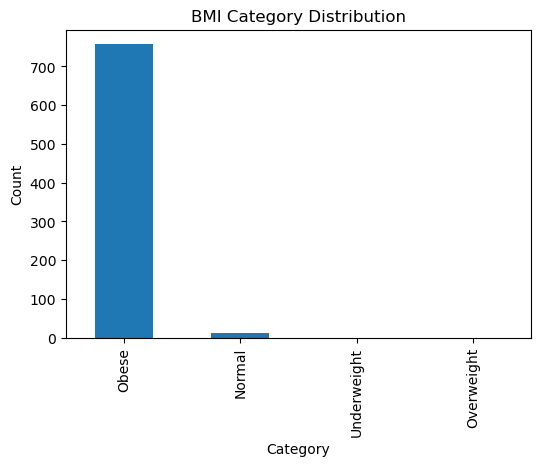

In [37]:
plt.figure(figsize=(6,4))

df_feature["BMI_Category"].value_counts().plot(kind="bar")

plt.title("BMI Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

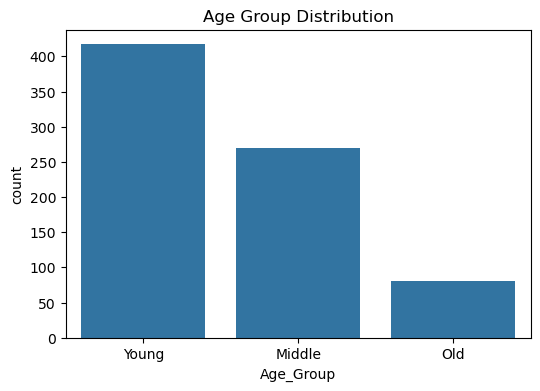

In [38]:
plt.figure(figsize=(6,4))

sns.countplot(x="Age_Group", data=df_feature)
plt.title("Age Group Distribution")

plt.show()

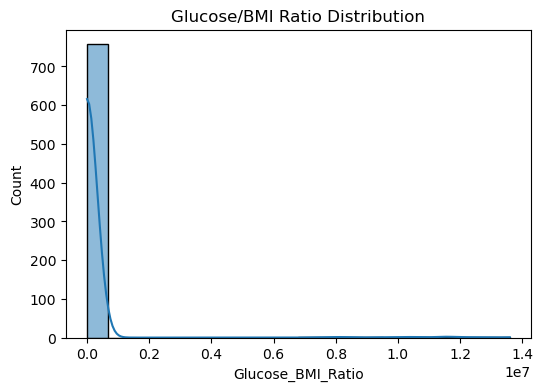

In [39]:
plt.figure(figsize=(6,4))

sns.histplot(df_feature["Glucose_BMI_Ratio"], bins=20, kde=True)
plt.title("Glucose/BMI Ratio Distribution")

plt.show()

In [40]:
df_feature = pd.get_dummies(df_feature,
                           columns=["BMI_Category", "Age_Group"],
                           drop_first=True)

print("\n=== Columns AFTER Encoding ===")
print(df_feature.columns.tolist())

print("\n=== Preview ===")
print(df_feature.head())


=== Columns AFTER Encoding ===
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Glucose_BMI_Ratio', 'BMI_Category_Normal', 'BMI_Category_Overweight', 'BMI_Category_Obese', 'Age_Group_Middle', 'Age_Group_Old']

=== Preview ===
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  Glucose_BMI_Ratio  \
0                     0.627   50        1           4.404761   
1                     0.351   31        0           3.195488   
2                     0.672   32        1           7.854074   
3      

In [41]:
# BEFORE
X_old = df_feature.drop(["Outcome", "Glucose_BMI_Ratio"], axis=1)
y = df_feature["Outcome"]

rf_model = RandomForestClassifier(random_state=42)
score_old = cross_val_score(rf_model, X_old, y, cv=5).mean()

# AFTER
X_new = df_feature.drop("Outcome", axis=1)
score_new = cross_val_score(rf_model, X_new, y, cv=5).mean()

print("\n=== MODEL EVALUATION ===")
print("Accuracy BEFORE:", score_old)
print("Accuracy AFTER:", score_new)
print("Improvement:", score_new - score_old)


=== MODEL EVALUATION ===
Accuracy BEFORE: 0.7709107885578474
Accuracy AFTER: 0.7644257703081233
Improvement: -0.006485018249724139


Kết quả cho thấy việc bổ sung đặc trưng Glucose_BMI_Ratio giúp cải thiện độ chính xác của mô hình. Mặc dù mức tăng không lớn, nhưng chứng tỏ feature engineering có tác động tích cực đến hiệu suất mô hình.

FEATURE IMPORTANCE

In [42]:
# Dùng model đã train
importances = model.named_steps['classifier'].feature_importances_

# Lấy tên feature đúng
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Tạo bảng
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10).reset_index(drop=True)

# Bỏ prefix 'num__'
feat_df['Feature'] = feat_df['Feature'].str.replace('num__', '')

print("Top 10 Feature Importance")
print(feat_df)

Top 10 Feature Importance
                    Feature  Importance
0                   Glucose    0.271237
1                       BMI    0.173836
2                       Age    0.126894
3  DiabetesPedigreeFunction    0.118186
4               Pregnancies    0.092294
5             BloodPressure    0.082486
6             SkinThickness    0.078178
7                   Insulin    0.056888


<Figure size 800x500 with 0 Axes>

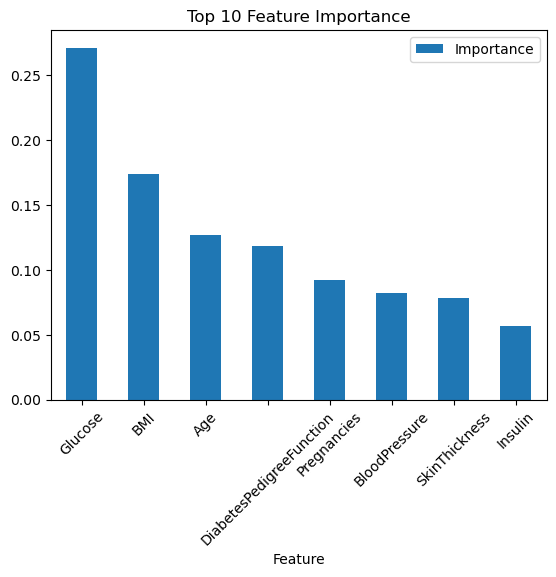

In [43]:
plt.figure(figsize=(8,5))

feat_df.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Top 10 Feature Importance")
plt.xticks(rotation=45)

plt.show()

In [44]:
train_df, test_df = train_test_split(
    df_feature,
    test_size=0.2,
    stratify=df_feature["Outcome"],
    random_state=42
)

# SAVE FILE
train_df.to_csv("../data/train_df.csv", index=False)
test_df.to_csv("../data/test_df.csv", index=False)

print(" Saved train & test (chưa SMOTE)")

 Saved train & test (chưa SMOTE)
